In [12]:
import matplotlib.pyplot as plt
import lightkurve as lk

# Render plots directly inside the notebook
%matplotlib inline 

# Search for Kepler-10 data from Quarter 4
search_result = lk.search_lightcurve('HAT-P-11',quarter=16 )
print(search_result)

# Download the LightCurve object
lc = search_result.download()


SearchResult containing 4 data products.

 #       mission      year author exptime  target_name  distance
                                     s                   arcsec 
--- ----------------- ---- ------ ------- ------------- --------
  0 Kepler Quarter 16 2013 Kepler      60 kplr010748390      0.0
  1 Kepler Quarter 16 2013 Kepler      60 kplr010748390      0.0
  2 Kepler Quarter 16 2013 Kepler      60 kplr010748390      0.0
  3 Kepler Quarter 16 2013 Kepler    1800 kplr010748390      0.0


/home/adamarthurryan/micromamba/envs/jupyter/lib/python3.13/site-packages/lightkurve/search.py:420: LightkurveWarning: Warning: 4 files available to download. Only the first file has been downloaded. Please use `download_all()` or specify additional criteria (e.g. quarter, campaign, or sector) to limit your search.
  warnings.warn(


Text(0.5, 1.0, 'Kepler-10 Raw SAP Flux')

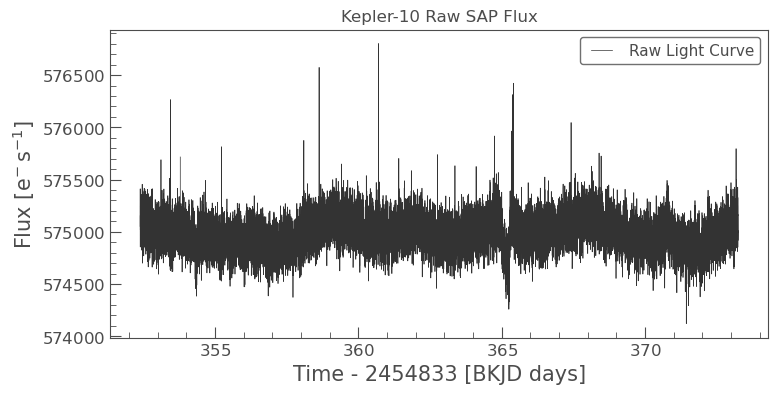

In [2]:
# Plot the raw data
lc.plot(label="Raw Light Curve")
plt.title("Kepler-10 Raw SAP Flux")


In [1]:
# Flatten the light curve to isolate sudden dips (transits)
flat_lc = lc.flatten(window_length=401)

# Remove cosmic ray outliers
clean_lc = flat_lc.remove_outliers()

# Plot the clean, flat timeline
clean_lc.plot(label="Flattened Data")
plt.title("Kepler-10 Detrended Light Curve")


NameError: name 'lc' is not defined

Text(0.5, 1.0, 'Kepler-10b Exoplanet Transit')

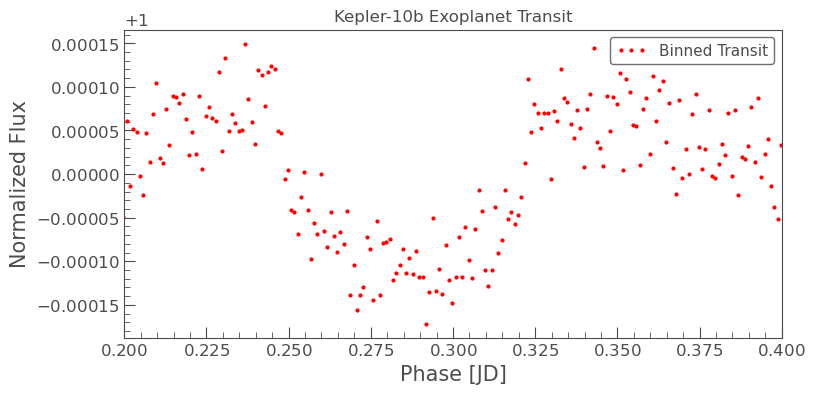

In [10]:
# Fold the light curve using the planet's orbital period
folded_lc = clean_lc.fold(period=0.83749070)

# Bin the data points to reduce noise and reveal the shape
binned_lc = folded_lc.bin(time_bin_size=0.001)

# Plot the final transit shape
binned_lc.plot(color='red', marker='o', linestyle='None', label='Binned Transit')
plt.xlim(0.2,0.4)  # Zoom into the transit event
plt.title("Kepler-10b Exoplanet Transit")
